# Level 1 · Part 1 — From raw spatial output to clean cells

*"What did the instrument measure, and which cells can we trust?"*

This section is a **MERSCOPE (MERFISH)** image of **developing human neocortex** — a thin tissue
slice in which a few hundred marker genes were imaged *in situ*, so every detected mRNA molecule
keeps its `(x, y)` position. Unlike dissociated single-cell RNA-seq, we keep **space**: where each
cell sits, who its neighbours are, how the tissue is layered.

The developing cortex has a stereotyped architecture we'll be able to see:

- **Progenitors** (radial glia, intermediate progenitor cells) line the ventricle in the
  **ventricular / subventricular zones (VZ/SVZ)**.
- Newborn neurons **migrate radially** outward and mature **excitatory (glutamatergic) neurons**
  settle into the **cortical plate** in layers (deep layers born first).
- **Inhibitory (GABAergic) interneurons** are born ventrally and migrate in tangentially.
- **Glia** — astrocytes and the oligodendrocyte lineage — and **microglia** and **vascular** cells
  appear and expand later; the **white matter** below the plate is enriched for glia and migrating cells.

Before any of that, though: what exactly did the instrument give us, and how good are the cells the
vendor's pipeline handed back?

## 0. Setup

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the `.pl` plotting accessor)
from spatialdata import bounding_box_query
from spatialdata.transformations import get_transformation

import warnings

warnings.simplefilter("ignore")  # keep the teaching output readable
sc.settings.verbosity = 1

# The section is staged ONCE, read-only, shared by everyone. We only read it here.
SHARED_ZARR = (
    "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/"
    "data/wang2025_merfish/processed/UCSF2018-003-MFG_baseline.zarr"
)

## 1. Load the data and look at its structure

The section is stored as a **SpatialData** object: a multiscale **image** (the stains), a **points**
element (every decoded transcript), a **shapes** element (the vendor's cell polygons), and a
**table** (cells × genes, with per-cell metadata).

In [3]:
sdata = sd.read_zarr(SHARED_ZARR)
sdata

SpatialData object, with associated Zarr store: /shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/data/wang2025_merfish/processed/UCSF2018-003-MFG_baseline.zarr
├── Images
│     └── 'raw_UCSF2018-003-MFG_z3': DataTree[cyx] (2, 81685, 122429), (2, 40842, 61214), (2, 20421, 30607), (2, 10210, 15303), (2, 5105, 7651)
├── Points
│     └── 'raw_UCSF2018-003-MFG_transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     └── 'authors_cells': GeoDataFrame shape: (90962, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (90962, 300)
with coordinate systems:
    ▸ 'global', with elements:
        raw_UCSF2018-003-MFG_z3 (Images), raw_UCSF2018-003-MFG_transcripts (Points), authors_cells (Shapes)

In [5]:
image_key = list(sdata.images)[0]
points_key = list(sdata.points)[0]
shapes_key = list(sdata.shapes)[0]

full_res = sdata[image_key]["scale0"]["image"]
print(
    "image  :",
    image_key,
    "| shape (C, Y, X) =",
    tuple(full_res.shape),
    "| channels:",
    [str(c) for c in full_res.coords["c"].values],
)
print("points :", points_key, "(individual transcripts)")
print("shapes :", shapes_key, "->", f"{len(sdata[shapes_key]):,}", "vendor cell polygons")
print("table  :", sdata["table"].shape, "(cells x genes)")
sdata["table"].obs.head()

image  : raw_UCSF2018-003-MFG_z3 | shape (C, Y, X) = (2, 81685, 122429) | channels: ['0', '1']
points : raw_UCSF2018-003-MFG_transcripts (individual transcripts)
shapes : authors_cells -> 90,962 vendor cell polygons
table  : (90962, 300) (cells x genes)


,fov,volume,center_x,center_y,min_x,max_x,min_y,max_y,region,cell_id
101067008445093297288543868591711571904,1708,432.610492,9022.967727,8675.046478,9016.271727,9029.663727,8667.756478,8682.336479,authors_cells,101067008445093297288543868591711571904
105357147726523176873582916346412554223,1708,402.031857,9006.551727,8694.864479,9000.719727,9012.383727,8686.980479,8702.748479,authors_cells,105357147726523176873582916346412554223
107772685775781971856545684617115638457,1708,514.041255,9171.683731,8651.070478,9164.231731,9179.135731,8643.996478,8658.144478,authors_cells,107772685775781971856545684617115638457
109560164495623483514085236461669788878,1708,1519.930087,9131.615730,8802.270482,9122.003730,9141.227730,8793.468482,8811.072482,authors_cells,109560164495623483514085236461669788878
124146632065535810248674469784684919963,1708,159.633512,9062.333728,8663.814478,9057.419728,9067.247728,8659.008478,8668.620478,authors_cells,124146632065535810248674469784684919963


❓ **Question.** The image is stored *multiscale* (a pyramid: `scale0`, `scale1`, …). Why is that
essential for a section that is ~100,000 × 80,000 pixels? *(Hint: what would it cost to draw the
full-resolution image just to preview the whole slide?)*

## 2. The whole section — nuclei and total RNA

Two stains: **DAPI** marks **nuclei**, **poly(T)** marks **total mRNA** (largely cytoplasmic, so it
approximates each cell's full extent). Together they outline where cells are — the raw material any
segmentation works from. The tissue is dim with a few bright spots, so we set the display contrast
from a percentile rather than the max.

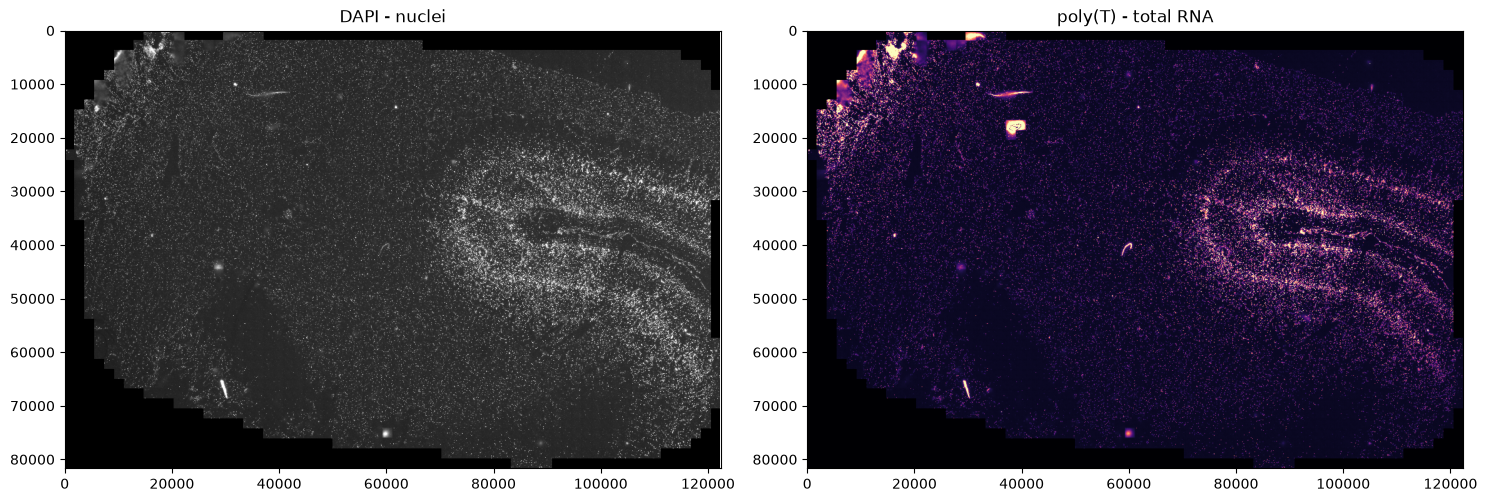

In [6]:
coarse = sdata[image_key]["scale4"]["image"]
dapi_norm = mcolors.Normalize(0, float(np.percentile(np.asarray(coarse.sel(c=0)), 99.5)))
polyt_norm = mcolors.Normalize(0, float(np.percentile(np.asarray(coarse.sel(c=1)), 99.5)))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sdata.pl.render_images(image_key, channel=0, cmap="gray", norm=dapi_norm, colorbar=False).pl.show(
    ax=axes[0], title="DAPI - nuclei"
)
sdata.pl.render_images(image_key, channel=1, cmap="magma", norm=polyt_norm, colorbar=False).pl.show(
    ax=axes[1], title="poly(T) - total RNA"
)
fig.tight_layout()

❓ **Question.** Where do you already see structure — a dense band (the cortical plate), sparser
zones, the ventricular edge? The way cells are packed changes across the tissue, and that will make
segmentation easier in some regions than others.

## 3. Zoom in — cells, boundaries, and transcripts

Zoom to a small window. The vendor segmented cells with the standard MERSCOPE approach: a **nuclear
(DAPI) seed** grown out with a **total-RNA (poly(T)) watershed**. Overlay those boundaries on DAPI,
then look at the raw transcripts they are meant to capture.

🔬 **TASK — See what segmentation has to work with.** In the code cell below (the zoomed `view` is
set up for you), build two side-by-side overlays on the same window: (left) the vendor cell
**boundaries** over DAPI, (right) the detected **transcripts** over DAPI.

💡 **HINT:** chain the `spatialdata-plot` accessor — `view.pl.render_images(...)` then
`.pl.render_shapes(...)` (boundaries) or `.pl.render_points(...)` (transcripts), then `.pl.show(ax=...)`.
Draw shapes with no fill so the DAPI shows through. See the
[spatialdata-plot docs](https://spatialdata.scverse.org/en/stable/).


In [7]:
affine = get_transformation(sdata[points_key], get_all=True)["global"]
M = affine.to_affine_matrix(input_axes=("x", "y"), output_axes=("x", "y"))
px_per_um = float(M[0, 0])

centroids = sdata[shapes_key].geometry.centroid
cx_um, cy_um = float(centroids.x.median()), float(centroids.y.median())
cx_px = M[0, 0] * cx_um + M[0, 1] * cy_um + M[0, 2]
cy_px = M[1, 0] * cx_um + M[1, 1] * cy_um + M[1, 2]

WIN_UM = 150
half = px_per_um * WIN_UM
view = bounding_box_query(
    sdata,
    axes=("x", "y"),
    min_coordinate=[cx_px - half, cy_px - half],
    max_coordinate=[cx_px + half, cy_px + half],
    target_coordinate_system="global",
)
print(f"1 micron = {px_per_um:.2f} pixels | window = {WIN_UM} um")

1 micron = 9.26 pixels | window = 150 um


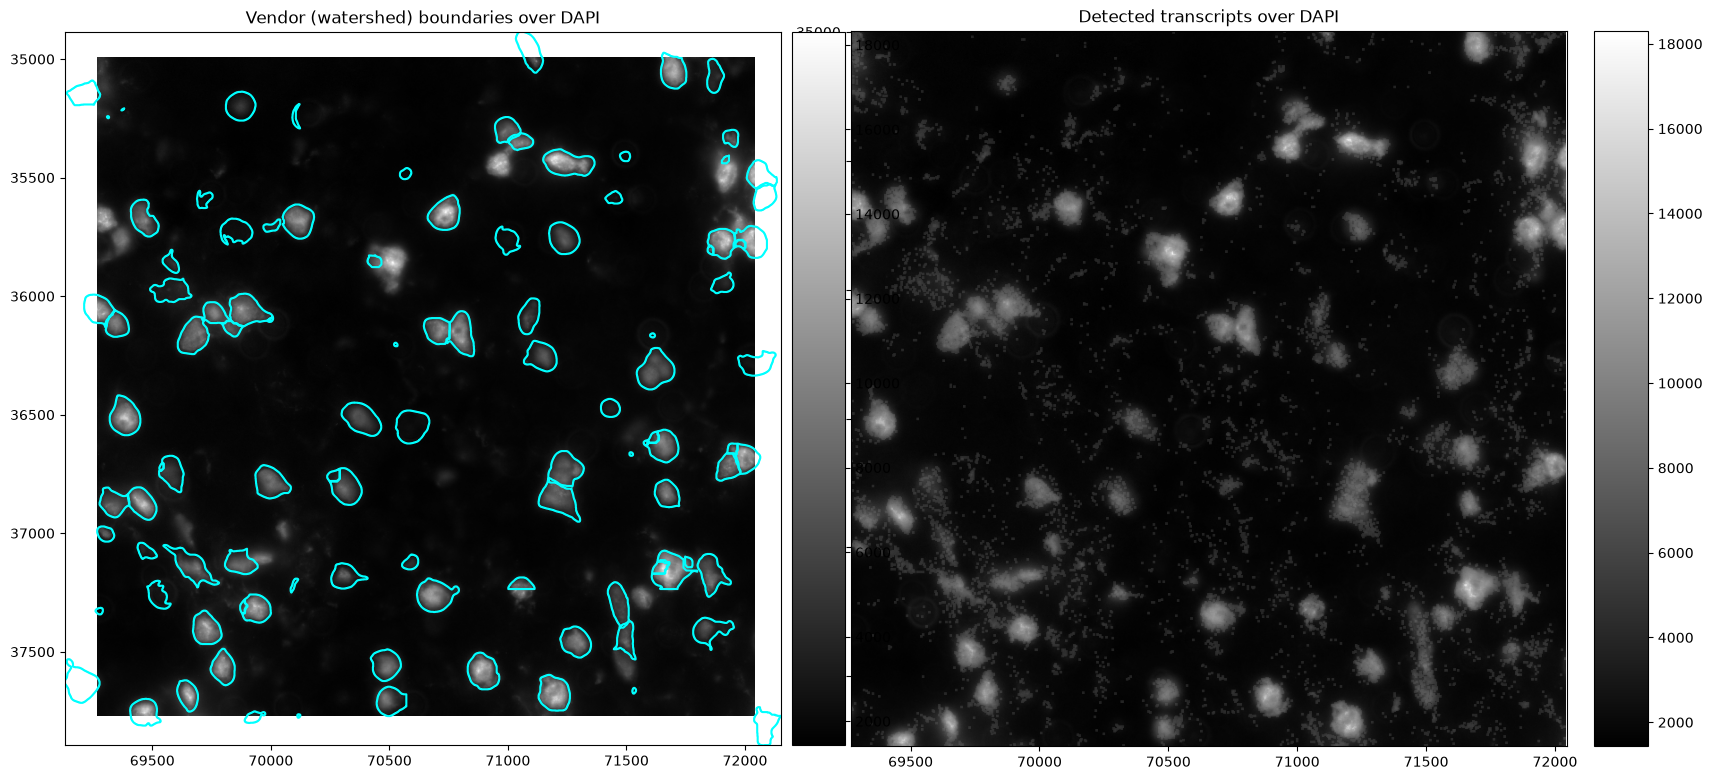

In [8]:
# 🔬 TASK (section 3) — build the two overlays on `view`; see the task + hint above.
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# LEFT — vendor cell boundaries over the DAPI (nuclei) stain
(
    view.pl.render_images(image_key, channel=0, cmap="gray")              # 1. DAPI as grayscale background
        .pl.render_shapes(shapes_key, fill_alpha=0,                       # 2. polygons with NO fill…
                          outline_alpha=1, outline_color="cyan")          #    …just cyan outlines
        .pl.show(ax=axes[0], title="Vendor (watershed) boundaries over DAPI")
)

# RIGHT — detected transcripts over the same DAPI background
(
    view.pl.render_images(image_key, channel=0, cmap="gray")             # same DAPI background
        .pl.render_points(points_key, color="gray", size=2, alpha=0.5)   # each mRNA molecule = one dot
        .pl.show(ax=axes[1], title="Detected transcripts over DAPI")
)
fig.tight_layout()

Each cyan outline is one vendor cell; each grey dot is one detected mRNA. Segmentation decides which
transcripts belong to which cell — and where boundaries touch, that decision is not obvious. **How
well the vendor did this is the subject of Part 2.**

## 4. Who is here? Marker genes in space

The panel targets cell-type markers, so we can already *see* the tissue's organisation. Colour every
cell by a canonical marker for each broad lineage. These are textbook developmental markers — no
clustering or annotation yet, just the raw signal in space.

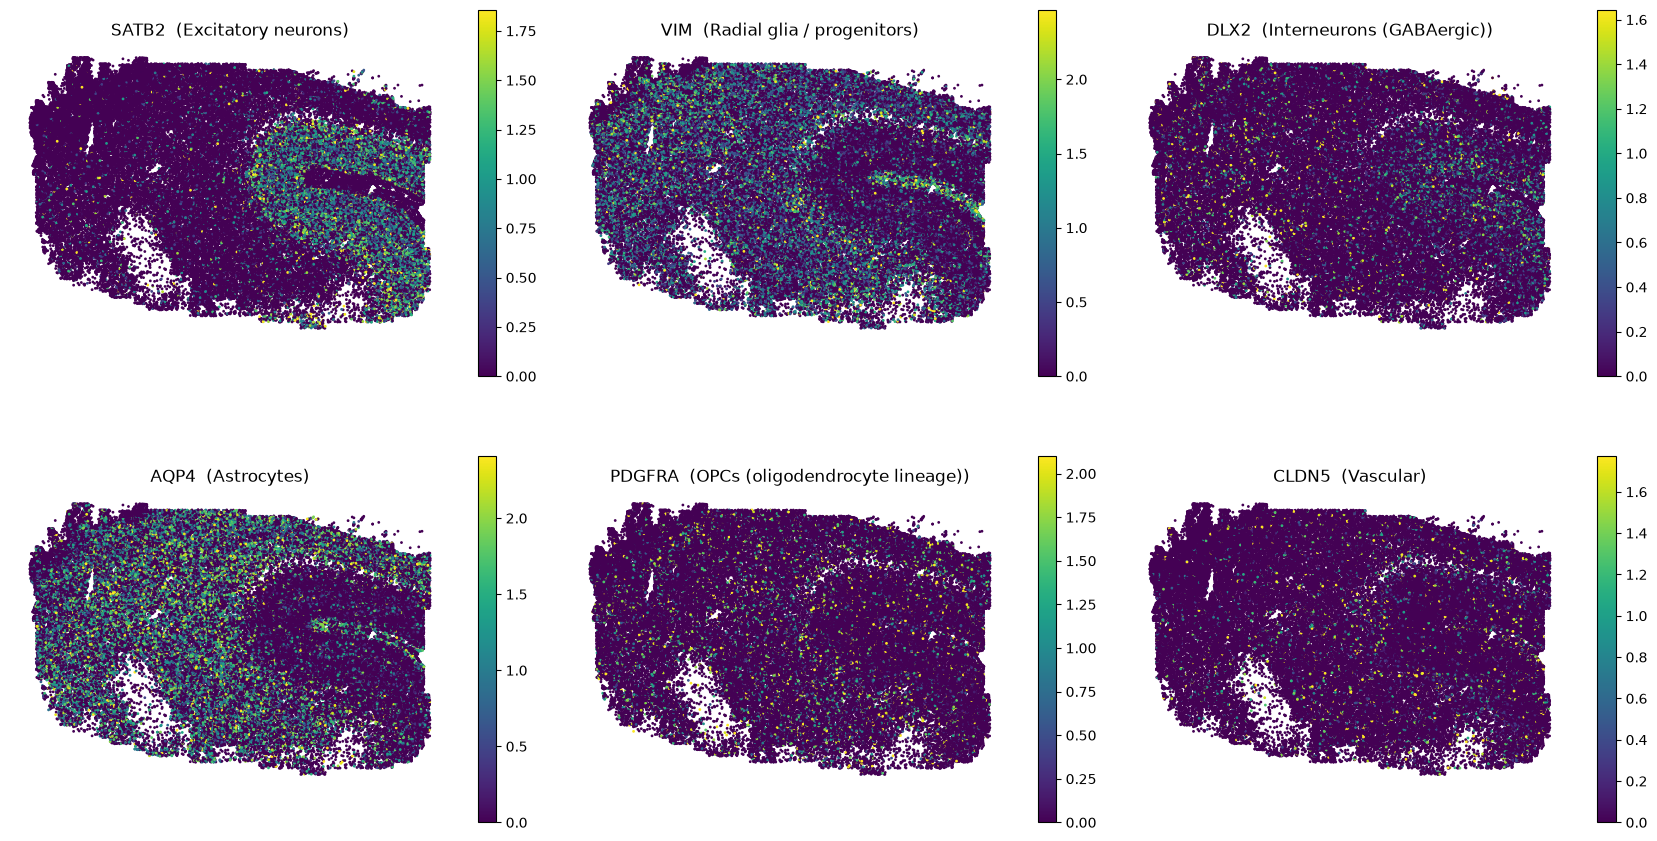

In [9]:
adata = sdata["table"].copy()
adata.layers["counts"] = adata.X.copy()  # keep the RAW counts (QC in section 5 needs them)

# For visualisation only, work on a *copy* that is normalised + log1p'd, and drop empty cells
# (a few vendor cells have zero counts). `adata` itself stays raw counts.
adata_norm = adata[np.asarray(adata.X.sum(axis=1)).ravel() > 0].copy()
sc.pp.normalize_total(adata_norm)
sc.pp.log1p(adata_norm)

# one representative in-panel marker per broad lineage (skip any not in this panel)
candidates = {
    "Excitatory neurons": "SATB2",
    "Radial glia / progenitors": "VIM",
    "Interneurons (GABAergic)": "DLX2",
    "Astrocytes": "AQP4",
    "OPCs (oligodendrocyte lineage)": "PDGFRA",
    "Vascular": "CLDN5",
}
markers = {lin: g for lin, g in candidates.items() if g in adata_norm.var_names}

xy_v = adata_norm.obsm["spatial"]
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax_, (lin, g) in zip(axes.ravel(), markers.items(), strict=False):
    expr = adata_norm[:, g].X
    expr = np.asarray(expr.todense()).ravel() if hasattr(expr, "todense") else np.asarray(expr).ravel()
    sca = ax_.scatter(xy_v[:, 0], xy_v[:, 1], c=expr, s=1, cmap="viridis", vmax=np.percentile(expr, 99))
    ax_.set(title=f"{g}  ({lin})")
    ax_.set_aspect("equal")
    ax_.invert_yaxis()
    ax_.axis("off")
    fig.colorbar(sca, ax=ax_, shrink=0.7)
for ax_ in axes.ravel()[len(markers) :]:
    ax_.axis("off")
fig.tight_layout()

❓ **Question.** Do the markers fall where the biology predicts — progenitor markers toward the
ventricular edge, neuronal markers in the plate, vascular in thin branching structures? This spatial
patterning is exactly the signal we would lose if segmentation smears transcripts across cells.

## 5. Quality control on the vendor cells

Not every segmented object is a good cell. Standard MERSCOPE QC looks at **transcripts per cell**,
**genes per cell**, and **cell volume**, and drops implausible objects (too few transcripts or genes,
or a volume too small to be a real cell). Typical MERSCOPE cells carry tens–hundreds of transcripts;
common cutoffs keep cells with a minimum number of counts and detected genes and a plausible volume,
and treat very high counts with suspicion (often merged **doublets**).

🔬 **TASK 5.1 — Compute the QC metrics.** On `adata` (raw counts), compute per-cell **transcripts**
and **genes** detected (volume is already in `.obs`), then look at the summary statistics.
💡 **HINT:** `sc.pp.calculate_qc_metrics` (with `percent_top=None`, `inplace=True`) writes
`total_counts` and `n_genes_by_counts` into `.obs`; then `.obs[[...]].describe()`.

🔬 **TASK 5.2 — Look at the distributions.** Plot a histogram of transcripts/cell, genes/cell, and
volume. 💡 **HINT:** one `plt.hist` per metric; add a median line so you can see the low shoulder
where a cutoff would naturally sit. (You *decide* the cutoffs in the question below — we don't apply
them here; these 90,962 cells are already the vendor's post-QC set.)


In [10]:
# TODO (exercise): implement this step — see the section text above.
qc_cols = ["total_counts", "n_genes_by_counts", "volume"]
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
adata.obs[qc_cols].describe().round(1)

,total_counts,n_genes_by_counts,volume
count,90962.0,90962.0,90962.0
mean,61.3,23.5,758.4
std,77.9,22.2,523.6
min,0.0,0.0,0.0
25%,5.0,4.0,284.9
50%,35.0,19.0,703.6
75%,88.0,36.0,1174.2
max,1984.0,160.0,10119.4


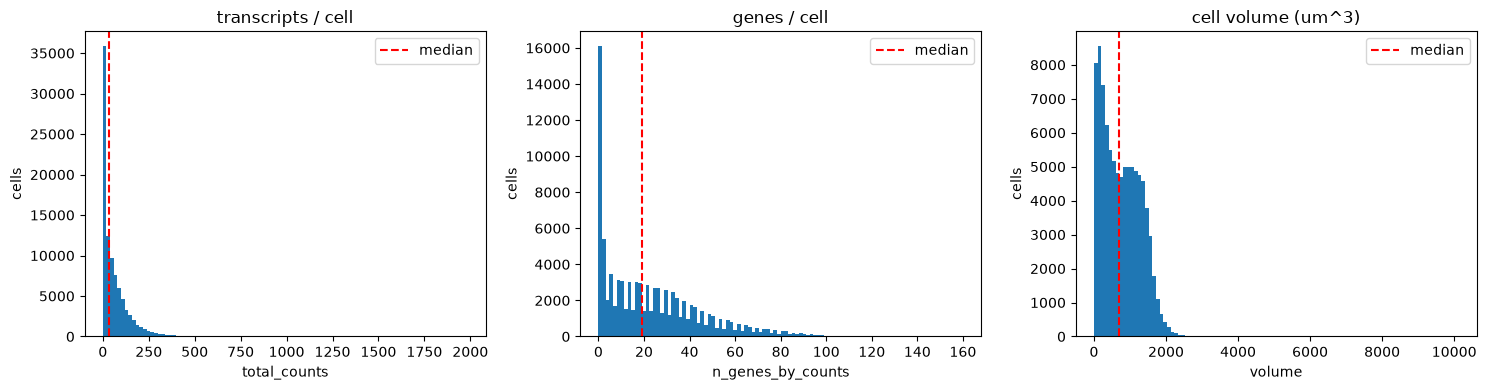

In [11]:
# TODO (exercise): implement this step — see the section text above.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax_, col, label in zip(
    axes,
    qc_cols,                                              # ["total_counts", "n_genes_by_counts", "volume"]
    ["transcripts / cell", "genes / cell", "cell volume (um^3)"],
    strict=False,
):
    ax_.hist(adata.obs[col], bins=100)                    # 1. the distribution
    ax_.axvline(adata.obs[col].median(), color="red", ls="--", label="median")  # 2. median marker
    ax_.set(title=label, xlabel=col, ylabel="cells")
    ax_.legend()
fig.tight_layout()

In [ ]:
# QC is also spatial: a detection gradient across the imaging area would show up here.
xy = adata.obsm["spatial"]  # all cells (raw table), aligned to the QC metrics above
vmax = np.percentile(adata.obs["total_counts"], 99)
fig, ax = plt.subplots(figsize=(9, 7))
sca = ax.scatter(xy[:, 0], xy[:, 1], c=adata.obs["total_counts"], s=2, cmap="viridis", vmax=vmax)
ax.set(title="transcripts / cell, in space", xlabel="x (um)", ylabel="y (um)")
ax.set_aspect("equal")
ax.invert_yaxis()
fig.colorbar(sca, ax=ax, label="transcripts / cell")

❓ **Question.** From the histograms, roughly where would *you* put the cutoffs for too-few
transcripts, too-few genes, and implausible volume? A subtle failure mode is a **doublet**: one
segmented object that merged two cells, which shows up as unusually high counts *and* co-expression
of markers from mutually-exclusive lineages (e.g. a neuronal and a glial marker in the same cell).
Hold that thought — leakage across boundaries is exactly what Part 2 measures.

## Summary & what's next

We loaded the section, saw its stains and structure, previewed the tissue's lineages in space, and
QC'd the vendor cells. The recurring question — *which transcripts belong to which cell* — is a
**segmentation** question. In **Part 2** we re-segment a crop of this tissue several ways and measure,
concretely, how much signal each method captures and how clean its cells are — using, for the
cleanliness metric, an independent lineage reference of the same tissue.

**Further reading.**
- **SpatialData** (the container you just navigated): [docs](https://spatialdata.scverse.org/) ·
  **Sopa** (the Level-1 segmentation engine): [docs](https://gustaveroussy.github.io/sopa/) ·
  **squidpy** (spatial analysis, Level 2): [docs](https://squidpy.readthedocs.io/).
- MERSCOPE/MERFISH QC and best practice for imaging-based spatial data: Salas et al.,
  *Optimizing Xenium In Situ data utility* (Nat. Methods 2025,
  [10.1038/s41592-025-02617-2](https://doi.org/10.1038/s41592-025-02617-2)) — the same group behind the
  segmentation-quality metric we use in Part 2.

🚀 **Going further (optional — open-ended).** Pick your own QC thresholds from the distributions above,
apply them to a *copy* of `adata`, and report how many cells each cutoff removes. Then plot the
**dropped** cells in space — are they scattered randomly, or concentrated in one region (e.g. a tissue
edge or a low-detection patch)? What would a spatial cluster of dropped cells tell you?
